In [8]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Dict , List 
import random 

In [9]:
class AgentState(TypedDict):
    name : str 
    number : List[int]
    counter : int 

In [10]:
def greeting_node(state : AgentState) -> AgentState:
    """This node will greet the user"""
    state["name"] = f'Hi there , {state["name"]}'
    state['counter'] = 0

    return state 

def random_node(state : AgentState) -> AgentState:
    """This node will generate a random number"""
    state['number'].append(random.randint(0,10))
    state['counter'] += 1
    return state 

def should_continue(state : AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state['counter'] < 5: 
        print("Entering loop ", state['counter'])
        return 'loop'
    else : 
        return 'exit' #Exit the loop 

In [12]:
#greeting -> random -> random -> random -> random -> random -> END

graph = StateGraph(AgentState)
graph.add_node('greeting' , greeting_node)
graph.add_node('random' , random_node)
graph.add_edge('greeting' , 'random')
graph.add_edge(START , 'greeting')

graph.add_conditional_edges(
    'random', 
    should_continue,
    {
        'loop' : 'random',
        'exit' : END
    }
)

app = graph.compile()




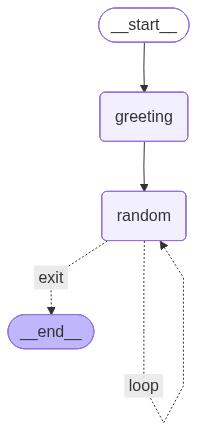

In [13]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [14]:
app.invoke({'name' : 'John', 'number' : [], 'counter':3023})

Entering loop  1
Entering loop  2
Entering loop  3
Entering loop  4


{'name': 'Hi there , John', 'number': [0, 9, 5, 8, 7], 'counter': 5}

------------------------

In [58]:
import random
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

# --------------------------------------------------
# State definition
# --------------------------------------------------
class AgentState(TypedDict):
    name: str
    Guessed_number: List[int]
    lower_bound: int
    upper_bound: int
    counter: int
    target_number: int


# --------------------------------------------------
# Setup node (state mutation)
# --------------------------------------------------
def setup(state: AgentState) -> AgentState:
    state["Guessed_number"] = []
    state["lower_bound"] = 0
    state["upper_bound"] = 10
    state["counter"] = 0
    return state


# --------------------------------------------------
# Guess node (state mutation)
# --------------------------------------------------
def guess(state: AgentState) -> AgentState:
    state["counter"] += 1
    guess_value = random.randint(state["lower_bound"], state["upper_bound"])
    state["Guessed_number"].append(guess_value)
    return state


# --------------------------------------------------
# Router node (decision only)
# --------------------------------------------------
def looping_condition(state: AgentState) -> str:
    # Safety stop
    if state["counter"] >= 5:
        print(f"{state['counter']} ❌ Limit reached, exiting")
        return "exit"

    last_guess = state["Guessed_number"][-1]
    target = state["target_number"]

    if last_guess == target:
        print(f"✅ Number guessed {state['target_number']}, exiting")
        return "exit"
    elif last_guess < target:
        print(state["counter"],f" ⬆️ Go higher {state['Guessed_number'][-1]}")
        return "go_higher"
    else:
        print(state["counter"],f" ⬇️ Go lower {state['Guessed_number'][-1]}")
        return "go_lower"


# --------------------------------------------------
# Build graph
# --------------------------------------------------
graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("router", lambda state : state)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "router")

graph.add_conditional_edges(
    "router",
    looping_condition,
    {
        "go_higher": "guess",   # 🔁 loop
        "go_lower": "guess",    # 🔁 loop
        "exit": END             # 🛑 stop
    }
)

app = graph.compile()


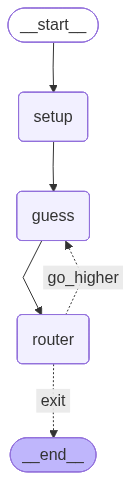

In [59]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [60]:
input_state = {
    "name": "Zaid",
    "target_number": 7
}


In [61]:
result = app.invoke(input_state)
print(result)


1  ⬆️ Go higher 1
2  ⬇️ Go lower 9
✅ Number guessed 7, exiting
{'name': 'Zaid', 'Guessed_number': [1, 9, 7], 'lower_bound': 0, 'upper_bound': 10, 'counter': 3, 'target_number': 7}
